## PLNet Prediction Visualization on Oxparis
In this notebook, we visualize the point and line predictions of PLNet on the Oxparis (MiniDepth) dataset.

### Imports

In [1]:
import torch
from matplotlib import pyplot as plt
from gluefactory.datasets import get_dataset
from gluefactory.models import get_model

### Define utility functions

In [2]:
def plot_images(images, titles=None, cmaps='gray', figsize=(20, 10)):
    n = len(images)
    fig, ax = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        ax = [ax]
    for i in range(n):
        ax[i].imshow(images[i], cmap=cmaps[i] if isinstance(cmaps, list) else cmaps)
        if titles:
            ax[i].set_title(titles[i])
        ax[i].axis('off')
    plt.show()

def plot_lines(lines, line_scores=None, ax=None, color='r', linewidth=1, alpha=1.0):
    if ax is None:
        ax = plt.gca()
    for i, line in enumerate(lines):
        if line_scores is not None:
            a = alpha * line_scores[i]
        else:
            a = alpha
        ax.plot([line[0, 0], line[1, 0]], [line[0, 1], line[1, 1]], color=color, linewidth=linewidth, alpha=a)

def get_model_size_on_gpu(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_all_mb = (param_size + buffer_size) / 1024**2
    print(f'Model size: {size_all_mb:.3f} MB')
    
    if torch.cuda.is_available():
        # This is just a rough estimate of memory used by the model on GPU
        print(f'Active GPU memory: {torch.cuda.memory_allocated() / 1024**2:.3f} MB')
        print(f'Max GPU memory: {torch.cuda.max_memory_allocated() / 1024**2:.3f} MB')


### Load the Dataset

In [3]:
dset_conf = {
    "name": "minidepth",
    "train_batch_size": 1,
    "val_batch_size": 1,
    "test_batch_size": 1,
    "reshape": 800,
    "load_features": {
        "do": False,
        "check_exists": True,
        "point_gt": {
            "data_keys": ["gt_keypoints", "gt_keypoints_scores"],
            "use_superpoint_kp_gt": True,
        },
        "line_gt": {
            "data_keys": ["deeplsd_distance_field", "deeplsd_angle_field"],
        },
    },
}
dataset = get_dataset("minidepth")(dset_conf)
loader = dataset.get_dataset(split="val")
print(f"Dataset size: {len(loader)}")


[01/25/2026 20:01:29 gluefactory.datasets.base_dataset INFO] Creating dataset MiniDepthDataset
/local/home/sak/glue-factory/gluefactory/datasets/augmentations.py:130: UserWarning: Argument(s) 'always_apply' are not valid for transform FromFloat
  self.preprocess = A.FromFloat(always_apply=True, dtype="uint8")
/local/home/sak/glue-factory/gluefactory/datasets/augmentations.py:131: UserWarning: Argument(s) 'always_apply' are not valid for transform ToFloat
  self.postprocess = A.ToFloat(always_apply=True)
[01/25/2026 20:01:29 gluefactory.datasets.minidepth INFO] NUMBER OF IMAGES: 850


Dataset size: 850


In [4]:
import gluefactory.models.extractors.pl_net_extractor

Successfully imported PLNet components from  /local/home/sak/glue-factory/other/PLNet


### Initialize PLNet

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plnet_conf = {
    "name": "extractors.pl_net_extractor",
    "max_num_junctions": 512,
    "max_num_lines": 512,
    "junction_threshold": 0.008,
    "line_threshold": 0.05,
}
model = get_model("extractors.pl_net_extractor")(plnet_conf).to(device)
model.eval()

print("Model information:")
get_model_size_on_gpu(model)


Initialize PLNet....
Loaded SuperPoint model
Model information:
Model size: 33.540 MB
Active GPU memory: 33.600 MB
Max GPU memory: 33.600 MB


### Run Inference and Visualize

In [ ]:
def visualize_predictions(data, model, device):
    img = data["image"].to(device).unsqueeze(0)
    with torch.no_grad():
        pred = model({"image": img})
    
    kpts = pred["keypoints"][0].cpu().numpy()
    lines = pred["lines"][0].cpu().numpy()
    
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    
    # Plot junctions
    ax[0].imshow(data["image"].permute(1, 2, 0), cmap='gray')
    ax[0].scatter(kpts[:, 0], kpts[:, 1], s=10, c='r', marker='o')
    ax[0].set_title(f"PLNet Junctions ({len(kpts)})")
    ax[0].axis('off')
    
    # Plot lines
    ax[1].imshow(data["image"].permute(1, 2, 0), cmap='gray')
    plot_lines(lines, ax=ax[1], color='r', linewidth=1)
    ax[1].set_title(f"PLNet Lines ({len(lines)})")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()


Example 0
torch.Size([1, 3, 536, 800])
Padded image size:  torch.Size([1, 3, 576, 832])
[[7.0194202e+02 2.4929782e+02]
 [5.9033539e+02 3.8251862e+02]
 [6.8996960e+02 2.0644443e+02]
 [7.6242694e+02 2.1384883e+02]
 [5.9757574e+02 2.2154727e+02]
 [6.9008539e+02 2.2587195e+02]
 [6.2956842e+02 1.9027914e+02]
 [7.3446130e+02 2.1057860e+02]
 [6.1385187e+02 3.5371191e+02]
 [6.7439764e+02 2.0522195e+02]
 [7.3487555e+02 2.2969586e+02]
 [5.6296021e+02 3.8234015e+02]
 [4.7239250e+01 6.5818443e+01]
 [7.4892920e+02 2.3068147e+02]
 [5.6261438e+02 3.1459924e+02]
 [7.0536871e+02 2.2679236e+02]
 [7.7671686e+02 2.3395421e+02]
 [2.7112694e+01 3.8205396e+02]
 [6.5849969e+02 2.0263954e+02]
 [6.1096350e+02 1.9905449e+02]
 [6.7482092e+02 2.2503488e+02]
 [6.2924146e+02 3.7770917e+02]
 [7.9939337e+02 9.9437392e-01]
 [7.7918029e-01 5.3528741e+02]
 [7.4020529e-01 3.8212833e+02]
 [2.2983131e+02 2.5441287e+02]
 [5.9144128e+02 3.1301083e+02]
 [7.0515753e+02 2.0887999e+02]
 [7.6299298e+02 2.3292679e+02]
 [6.0123273e+

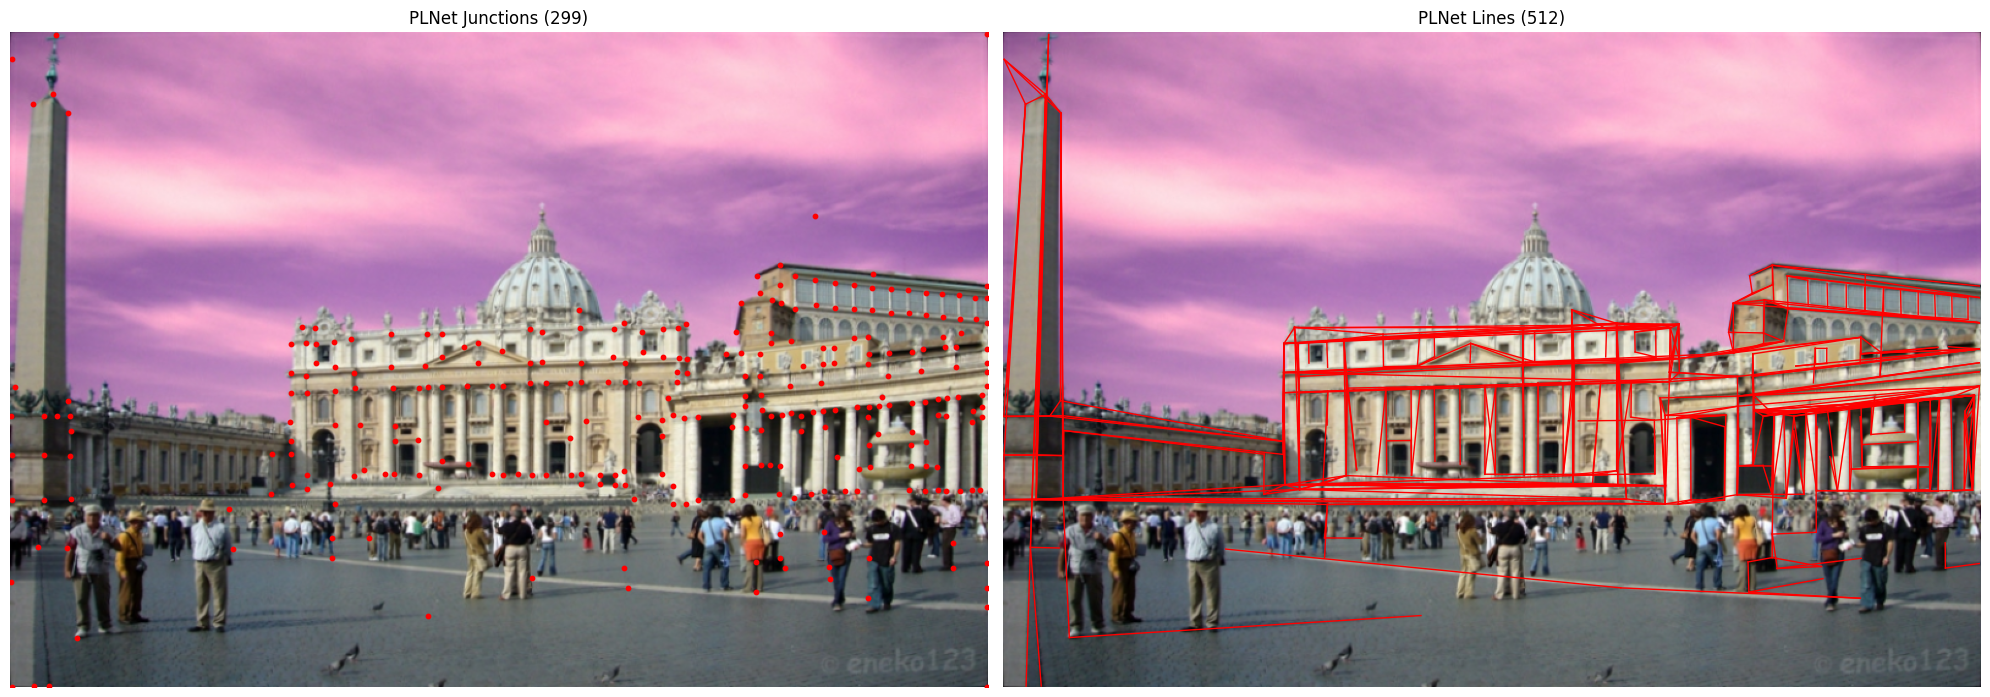

Example 1
torch.Size([1, 3, 592, 800])
Padded image size:  torch.Size([1, 3, 640, 832])
[[5.30377380e+02 2.98386597e+02]
 [5.30185425e+02 2.82173920e+02]
 [2.45962280e+02 3.01937714e+02]
 [5.93326782e+02 2.74339325e+02]
 [5.93869385e+02 2.97358704e+02]
 [5.82538208e+02 4.50284607e+02]
 [2.46100571e+02 2.86998291e+02]
 [2.58693604e+02 3.01915100e+02]
 [4.97891307e-01 3.61665375e+02]
 [5.53468262e+02 4.50421478e+02]
 [4.85463196e+02 2.98014832e+02]
 [2.06315323e+02 3.02669342e+02]
 [2.78992950e+02 3.33946777e+02]
 [3.82027435e+02 2.78738983e+02]
 [5.37439331e+02 4.41245026e+02]
 [4.09903412e+02 4.02189667e+02]
 [4.29497620e+02 4.01940887e+02]
 [3.05459290e+02 2.86463470e+02]
 [1.90795868e+02 2.81290680e+02]
 [1.89684662e+02 3.02545654e+02]
 [4.89536047e-01 3.77453278e+02]
 [5.75190735e+02 2.74427063e+02]
 [4.30096954e+02 3.81206268e+02]
 [2.59286407e+02 2.86438049e+02]
 [5.15198914e+02 2.82536407e+02]
 [2.06959076e+02 2.80874268e+02]
 [3.66659424e+02 3.78345612e+02]
 [4.10308502e+02 3.81

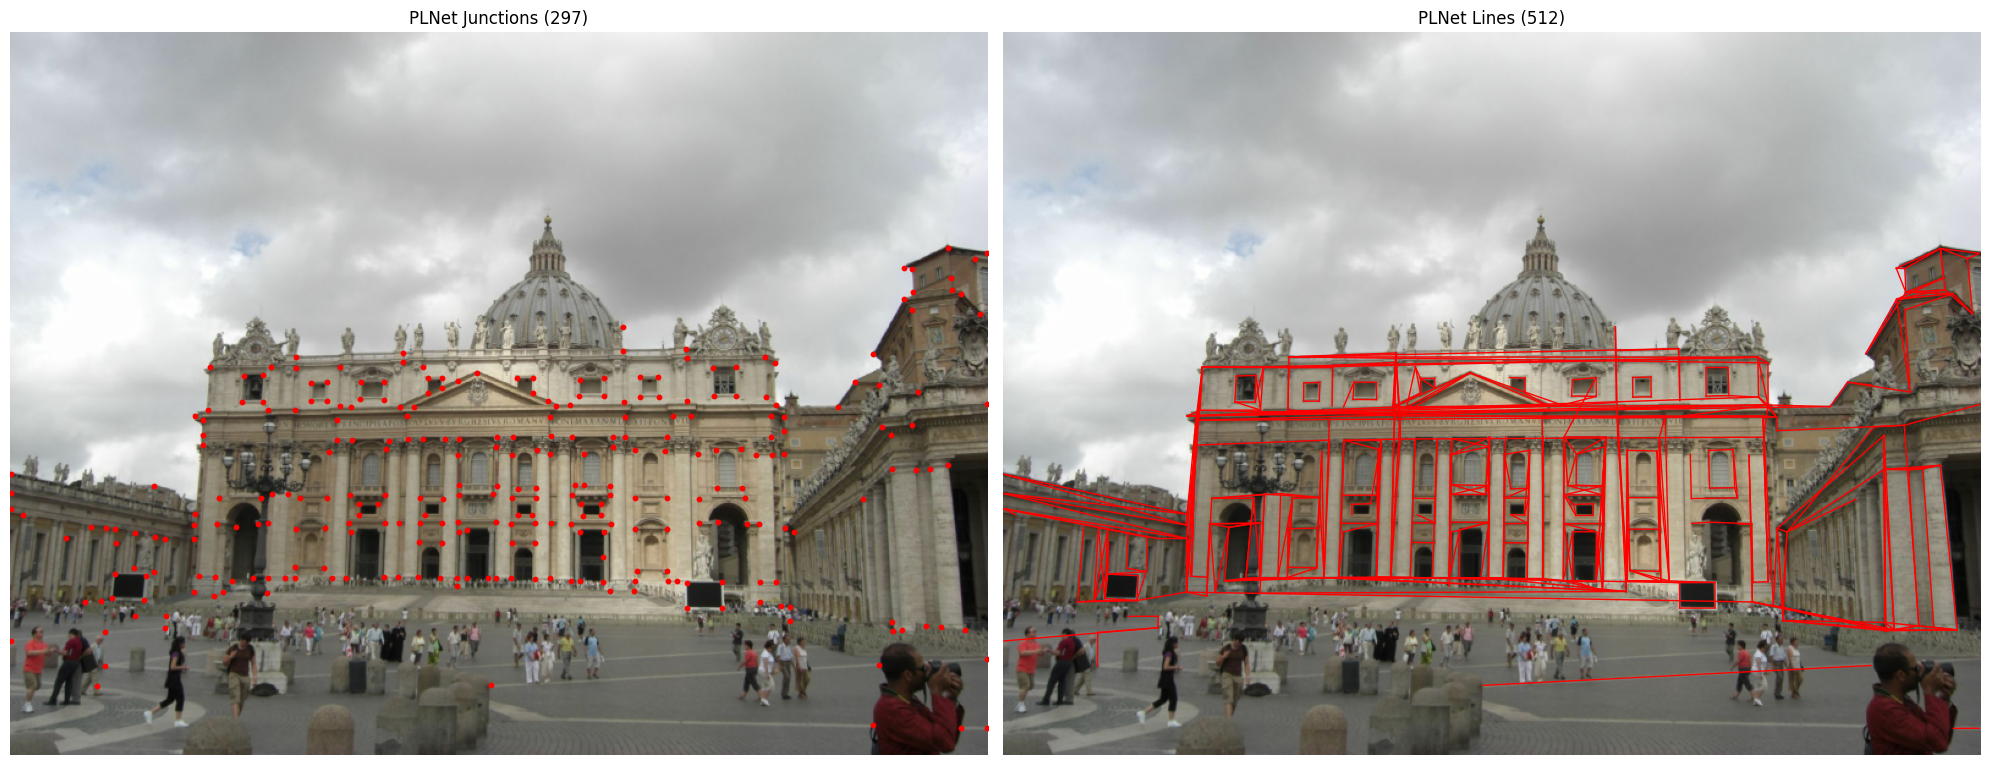

Example 2
torch.Size([1, 3, 596, 800])
Padded image size:  torch.Size([1, 3, 640, 832])
[[2.10878845e+02 2.89770264e+02]
 [7.46046753e+02 6.21603317e+01]
 [7.78223816e+02 2.30286484e+02]
 [7.49334290e+02 1.30410141e+02]
 [7.37920959e+02 1.10400124e+02]
 [7.25878296e+02 2.30547577e+02]
 [7.14201660e+02 9.43850403e+01]
 [7.21683289e+02 8.66172409e+01]
 [6.90104248e+02 3.02420776e+02]
 [7.78698425e+02 1.06743286e+02]
 [6.69733337e+02 4.11305481e+02]
 [7.50474060e+02 2.17645615e+02]
 [7.46506775e+02 1.02517365e+02]
 [1.88400955e+01 3.17195953e+02]
 [7.37447449e+02 7.07773285e+01]
 [4.73706909e+02 3.89025177e+02]
 [6.21488831e+02 4.53821655e+02]
 [2.28920212e+02 2.33860046e+02]
 [7.03371216e+02 1.66646637e+02]
 [7.13672485e+02 1.58095612e+02]
 [3.41755341e+02 3.41113342e+02]
 [7.63313171e+02 1.18389305e+02]
 [7.02887695e+02 2.98050446e+02]
 [7.01538025e+02 1.42243607e+02]
 [7.14341187e+02 1.30598129e+02]
 [2.97559814e+02 3.13786804e+02]
 [7.66862488e+02 2.34594391e+02]
 [6.33929993e+02 1.74

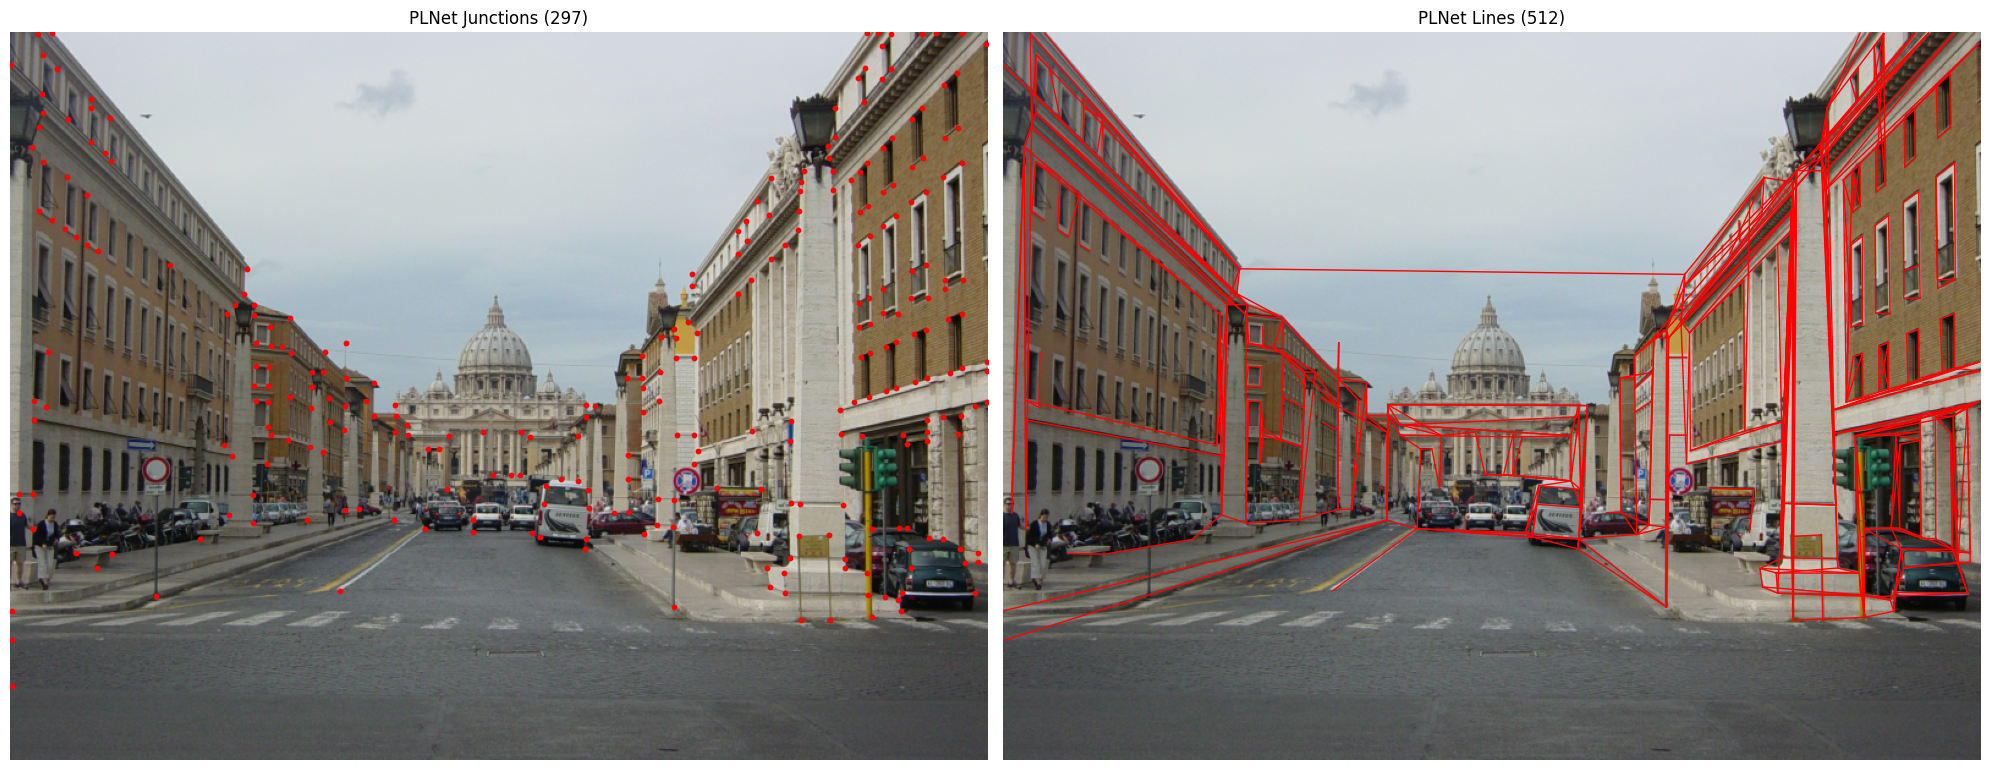

In [7]:
# Visualize a few examples
for i in range(3):
    print(f"Example {i}")
    data = loader[i]
    visualize_predictions(data, model, device)
